# COAD Gene Expression Analysis Report

**Date:** 2026-06-13  
**Cancer type:** COAD means colon adenocarcinoma (a type of colon cancer / 一种结肠癌).  
**Main question:** Which genes are expressed differently in tumor tissue compared with normal colon tissue?

Gene expression (基因表达 / 一个基因在细胞里“开得多强”) can help us find genes that behave differently between cancer and normal tissue.

This notebook includes:

1. Tumor vs normal differential expression analysis (差异表达分析 / 找出癌组织和正常组织中表达量明显不同的基因).
2. Top upregulated genes (上调基因 / 癌症中表达更高的基因).
3. Top downregulated genes (下调基因 / 癌症中表达更低的基因).
4. Volcano plot (火山图 / 显示基因差异大小和显著性的图).
5. Heatmap (热图 / 用颜色显示基因表达强弱).


## Method Summary

- **Expression scale:** statistical tests use `log2(expression + 1)`, which makes very large expression values easier to compare.
- **Fold change:** `log2 fold change` compares average raw expression in tumor vs normal. Positive values mean higher in tumor; negative values mean lower in tumor.
- **Welch t-test:** compares tumor and normal expression for each gene, allowing the two groups to have different variance (方差：数据分散程度).
- **FDR / q-value:** false discovery rate correction (多重检验校正 / because thousands of genes are tested at once, we control false positives).

Important caveat: tumor samples are from TCGA and normal samples are from GTEx colon normal data in this prepared dataset. That means batch/source effects (批次或来源效应 / differences caused by data source rather than biology) may remain.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130

REPORT_DIR = Path.cwd()
if REPORT_DIR.name != "reports":
    REPORT_DIR = Path("/workspace/coad-predictor-model/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = REPORT_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"

raw_path = DATA_DIR / "coad_tumor_normal_raw_expression.parquet"
log_path = DATA_DIR / "coad_tumor_normal_features.parquet"
labels_path = DATA_DIR / "coad_tumor_normal_labels.csv"
summary_path = DATA_DIR / "data_summary.json"

for path in [raw_path, log_path, labels_path]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required file: {path}. Run the COAD data preparation workflow first."
        )

print("Report directory:", REPORT_DIR)
print("Data directory:", DATA_DIR)

Report directory: /workspace/coad-predictor-model/reports
Data directory: /workspace/coad-predictor-model/data


## Load Expression Matrix and Labels

In [2]:
labels = pd.read_csv(labels_path)
raw_expr = pd.read_parquet(raw_path)
log_expr = pd.read_parquet(log_path)

if raw_expr.columns.duplicated().any():
    raw_expr = raw_expr.T.groupby(level=0).mean().T
if log_expr.columns.duplicated().any():
    log_expr = log_expr.T.groupby(level=0).mean().T
common_genes = raw_expr.columns.intersection(log_expr.columns)
raw_expr = raw_expr.loc[:, common_genes]
log_expr = log_expr.loc[:, common_genes]

shared_samples = labels[labels["sample_id"].isin(log_expr.index)]["sample_id"]
labels = labels.set_index("sample_id").loc[shared_samples].reset_index()
raw_expr = raw_expr.loc[shared_samples]
log_expr = log_expr.loc[shared_samples]

tumor_mask = labels["label"].eq("tumor").to_numpy()
normal_mask = labels["label"].eq("normal").to_numpy()

data_summary = json.loads(summary_path.read_text()) if summary_path.exists() else {}
summary_table = pd.DataFrame(
    {
        "metric": [
            "Samples",
            "Tumor samples",
            "Normal samples",
            "Genes",
            "Tumor source",
            "Normal source",
        ],
        "value": [
            len(labels),
            int(tumor_mask.sum()),
            int(normal_mask.sum()),
            log_expr.shape[1],
            data_summary.get("tumor_source", "unknown"),
            data_summary.get("normal_source", "unknown"),
        ],
    }
)
display(summary_table)
display(labels.head())

,metric,value
0,Samples,757
1,Tumor samples,449
2,Normal samples,308
3,Genes,17974
4,Tumor source,bio_tcga.matrix_rnaseq_gene_expression
5,Normal source,toil_gtex_colon_normal.expression_log2_tpm


,sample_id,sample_index,case_submitter_id,sample_type_code,source_schema,source_table,sample_type,sample_submitter_id,label,primary_site,gender,cohort
0,TCGA-3L-AA1B-01A-11R-A37K-07,3394.0,TCGA-3L-AA1B,1.0,bio_tcga,matrix_rnaseq_gene_expression,Primary Tumor,TCGA-3L-AA1B-01A-11R-A37K-07,tumor,NaN,NaN,NaN
1,TCGA-4N-A93T-01A-11R-A37K-07,3395.0,TCGA-4N-A93T,1.0,bio_tcga,matrix_rnaseq_gene_expression,Primary Tumor,TCGA-4N-A93T-01A-11R-A37K-07,tumor,NaN,NaN,NaN
2,TCGA-4T-AA8H-01A-11R-A41B-07,3396.0,TCGA-4T-AA8H,1.0,bio_tcga,matrix_rnaseq_gene_expression,Primary Tumor,TCGA-4T-AA8H-01A-11R-A41B-07,tumor,NaN,NaN,NaN
3,TCGA-5M-AAT4-01A-11R-A41B-07,3397.0,TCGA-5M-AAT4,1.0,bio_tcga,matrix_rnaseq_gene_expression,Primary Tumor,TCGA-5M-AAT4-01A-11R-A41B-07,tumor,NaN,NaN,NaN
4,TCGA-5M-AAT6-01A-11R-A41B-07,3399.0,TCGA-5M-AAT6,1.0,bio_tcga,matrix_rnaseq_gene_expression,Primary Tumor,TCGA-5M-AAT6-01A-11R-A41B-07,tumor,NaN,NaN,NaN


## Differential Expression Analysis

For each gene, this section calculates:

- Mean tumor expression.
- Mean normal expression.
- `log2_fold_change`.
- p-value from Welch t-test.
- q-value after FDR correction.


In [3]:
tumor_log = log_expr.loc[tumor_mask]
normal_log = log_expr.loc[normal_mask]
tumor_raw = raw_expr.loc[tumor_mask]
normal_raw = raw_expr.loc[normal_mask]

test = stats.ttest_ind(
    tumor_log.to_numpy(dtype=float),
    normal_log.to_numpy(dtype=float),
    axis=0,
    equal_var=False,
    nan_policy="omit",
)

mean_tumor_raw = tumor_raw.mean(axis=0)
mean_normal_raw = normal_raw.mean(axis=0)
mean_tumor_log = tumor_log.mean(axis=0)
mean_normal_log = normal_log.mean(axis=0)
log2_fc = np.log2((mean_tumor_raw + 1) / (mean_normal_raw + 1))

de = pd.DataFrame(
    {
        "gene_symbol": log_expr.columns,
        "mean_tumor_raw": mean_tumor_raw.values,
        "mean_normal_raw": mean_normal_raw.values,
        "mean_tumor_log2": mean_tumor_log.values,
        "mean_normal_log2": mean_normal_log.values,
        "log2_fold_change": log2_fc.values,
        "p_value": test.pvalue,
    }
)
de["p_value"] = de["p_value"].replace([np.inf, -np.inf], np.nan).fillna(1.0)
de["q_value"] = multipletests(de["p_value"], method="fdr_bh")[1]
de["minus_log10_q"] = -np.log10(de["q_value"].clip(lower=1e-300))
de["direction"] = np.select(
    [
        (de["q_value"] < 0.05) & (de["log2_fold_change"] >= 1),
        (de["q_value"] < 0.05) & (de["log2_fold_change"] <= -1),
    ],
    ["upregulated_in_tumor", "downregulated_in_tumor"],
    default="not_significant_or_small_effect",
)
de = de.sort_values(["q_value", "log2_fold_change"], ascending=[True, False])

all_path = REPORT_DIR / "coad_differential_expression_results.csv"
up_path = REPORT_DIR / "coad_top_upregulated_genes.csv"
down_path = REPORT_DIR / "coad_top_downregulated_genes.csv"
de.to_csv(all_path, index=False)

top_up = (
    de[de["direction"].eq("upregulated_in_tumor")]
    .sort_values(["log2_fold_change", "q_value"], ascending=[False, True])
    .head(25)
)
top_down = (
    de[de["direction"].eq("downregulated_in_tumor")]
    .sort_values(["log2_fold_change", "q_value"], ascending=[True, True])
    .head(25)
)
top_up.to_csv(up_path, index=False)
top_down.to_csv(down_path, index=False)

counts = de["direction"].value_counts().rename_axis("category").reset_index(name="genes")
display(counts)
display(Markdown(f"Full differential expression table saved to `{all_path}`."))

,category,genes
0,upregulated_in_tumor,14993
1,not_significant_or_small_effect,2873
2,downregulated_in_tumor,108


Full differential expression table saved to `/workspace/coad-predictor-model/reports/coad_differential_expression_results.csv`.

## Top Upregulated Genes

In [4]:
top_display_cols = [
    "gene_symbol",
    "log2_fold_change",
    "mean_tumor_raw",
    "mean_normal_raw",
    "q_value",
]
display(top_up[top_display_cols].round(4))
display(Markdown(f"Top upregulated table saved to `{up_path}`."))

,gene_symbol,log2_fold_change,mean_tumor_raw,mean_normal_raw,q_value
248,ADAM6,15.0982,35137.7707,0.0018,0.0
4468,EEF1A1P9,12.8840,9178.9709,0.2144,0.0
3010,CLDN2,11.6137,3762.8203,0.2011,0.0
4253,DPEP1,11.3124,4586.6221,0.8039,0.0
4587,EIF5AL1,10.6812,2209.6228,0.3463,0.0
16016,TNS4,10.5349,3031.9117,1.0442,0.0
2635,CDH3,10.5236,2001.3846,0.3603,0.0
3000,CLDN1,10.4895,2300.9596,0.6012,0.0
9952,NME2,10.4626,10563.1583,6.4866,0.0
4822,ETV4,10.4168,2600.9648,0.9034,0.0


Top upregulated table saved to `/workspace/coad-predictor-model/reports/coad_top_upregulated_genes.csv`.

## Top Downregulated Genes

In [5]:
display(top_down[top_display_cols].round(4))
display(Markdown(f"Top downregulated table saved to `{down_path}`."))

,gene_symbol,log2_fold_change,mean_tumor_raw,mean_normal_raw,q_value
13088,RPL21,-6.2248,12.3740,999.2551,0.0000
14672,SPATA4,-4.9664,0.1206,34.0332,0.0000
8015,KRTAP13-2,-4.9009,0.8440,54.0916,0.0316
5005,FAM166B,-4.7477,3.9557,132.1436,0.0000
12742,RERGL,-4.1701,2.3382,59.0958,0.0000
3716,CYP4B1,-4.0381,4.3697,87.2143,0.0000
7158,IGSF5,-4.0126,1.3470,36.8815,0.0000
17224,ZACN,-4.0053,0.6275,25.1365,0.0000
10634,OR5K2,-3.9758,0.2372,18.4658,0.0000
5,A4GNT,-3.6143,0.5193,17.6063,0.0492


Top downregulated table saved to `/workspace/coad-predictor-model/reports/coad_top_downregulated_genes.csv`.

## Volcano Plot

The volcano plot shows effect size on the x-axis and statistical strength on the y-axis. Genes far left or far right and high up are the most interesting candidates.


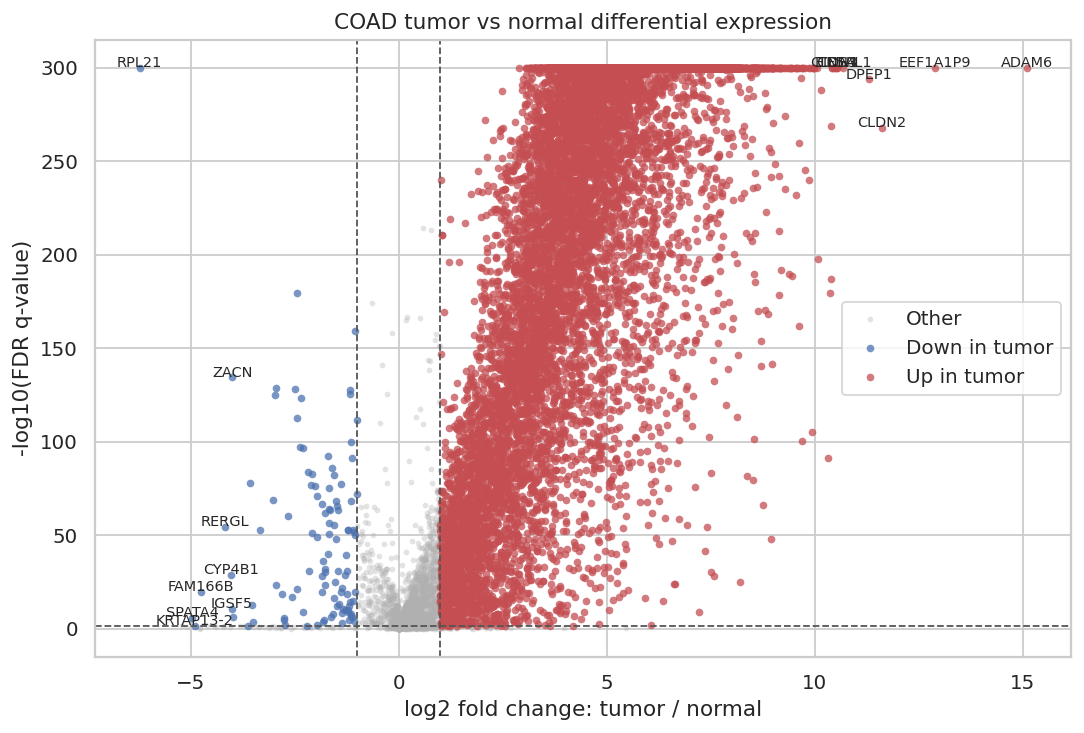

Volcano plot saved to `/workspace/coad-predictor-model/reports/coad_differential_expression_volcano.png`.

In [6]:
volcano_df = de.copy()
volcano_df["plot_group"] = volcano_df["direction"].map(
    {
        "upregulated_in_tumor": "Up in tumor",
        "downregulated_in_tumor": "Down in tumor",
        "not_significant_or_small_effect": "Other",
    }
)
palette = {
    "Up in tumor": "#C44E52",
    "Down in tumor": "#4C72B0",
    "Other": "#B0B0B0",
}

fig, ax = plt.subplots(figsize=(8.5, 5.8))
for group in ["Other", "Down in tumor", "Up in tumor"]:
    part = volcano_df[volcano_df["plot_group"].eq(group)]
    ax.scatter(
        part["log2_fold_change"],
        part["minus_log10_q"],
        s=10 if group == "Other" else 18,
        alpha=0.35 if group == "Other" else 0.75,
        c=palette[group],
        label=group,
        linewidths=0,
    )
ax.axvline(1, color="#555555", linestyle="--", linewidth=1)
ax.axvline(-1, color="#555555", linestyle="--", linewidth=1)
ax.axhline(-np.log10(0.05), color="#555555", linestyle="--", linewidth=1)

label_genes = pd.concat([top_up.head(8), top_down.head(8)])
for _, row in label_genes.iterrows():
    ax.text(
        row["log2_fold_change"],
        row["minus_log10_q"] + 0.3,
        row["gene_symbol"],
        fontsize=8,
        ha="center",
    )

ax.set_title("COAD tumor vs normal differential expression")
ax.set_xlabel("log2 fold change: tumor / normal")
ax.set_ylabel("-log10(FDR q-value)")
ax.legend(frameon=True)
fig.tight_layout()
volcano_path = REPORT_DIR / "coad_differential_expression_volcano.png"
fig.savefig(volcano_path, bbox_inches="tight")
plt.show()
display(Markdown(f"Volcano plot saved to `{volcano_path}`."))

## Heatmap of Top Differentially Expressed Genes

The heatmap uses z-scores (standardized expression / 标准化表达) so each gene can be compared by color even if the raw expression ranges are different. Red means higher than that gene's average; blue means lower.


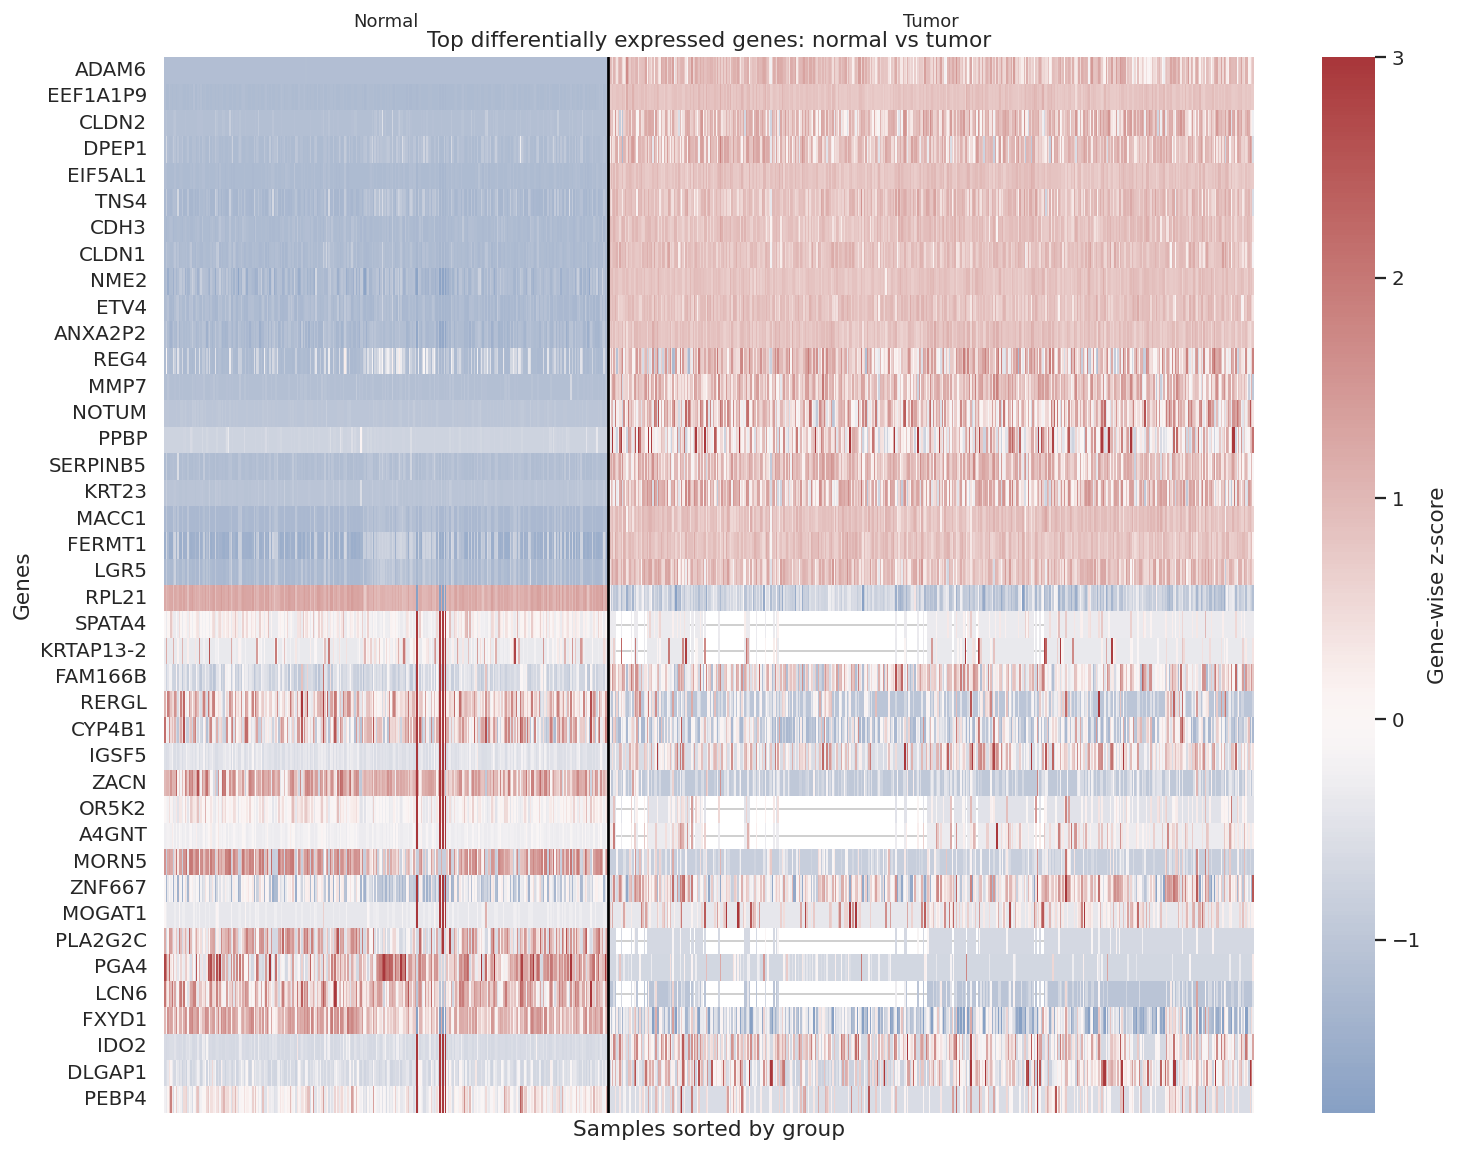

Heatmap saved to `/workspace/coad-predictor-model/reports/coad_differential_expression_heatmap.png`.

In [7]:
heatmap_genes = pd.concat([top_up.head(20), top_down.head(20)])["gene_symbol"].tolist()
heatmap_labels = labels.copy()
heatmap_labels["sort_group"] = heatmap_labels["label"].map({"normal": 0, "tumor": 1})
ordered_samples = heatmap_labels.sort_values(["sort_group", "sample_id"])["sample_id"].tolist()

heatmap_matrix = log_expr.loc[ordered_samples, heatmap_genes].T
gene_means = heatmap_matrix.mean(axis=1)
gene_stds = heatmap_matrix.std(axis=1).replace(0, np.nan)
heatmap_z = heatmap_matrix.sub(gene_means, axis=0).div(gene_stds, axis=0).clip(-3, 3)

normal_count = int((labels.set_index("sample_id").loc[ordered_samples, "label"] == "normal").sum())

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    heatmap_z,
    cmap="vlag",
    center=0,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={"label": "Gene-wise z-score"},
    ax=ax,
)
ax.axvline(normal_count, color="black", linewidth=1.5)
ax.text(normal_count / 2, -1.0, "Normal", ha="center", va="bottom", fontsize=10)
ax.text(normal_count + (len(ordered_samples) - normal_count) / 2, -1.0, "Tumor", ha="center", va="bottom", fontsize=10)
ax.set_title("Top differentially expressed genes: normal vs tumor")
ax.set_xlabel("Samples sorted by group")
ax.set_ylabel("Genes")
fig.tight_layout()
heatmap_path = REPORT_DIR / "coad_differential_expression_heatmap.png"
fig.savefig(heatmap_path, bbox_inches="tight")
plt.show()
display(Markdown(f"Heatmap saved to `{heatmap_path}`."))

## Final Summary

In [8]:
n_up = int((de["direction"] == "upregulated_in_tumor").sum())
n_down = int((de["direction"] == "downregulated_in_tumor").sum())
best_up = top_up.iloc[0]
best_down = top_down.iloc[0]

summary_text = f"""
### Answers

1. **Differential expression analysis:** using FDR q < 0.05 and |log2 fold change| >= 1, this analysis found **{n_up} upregulated genes** and **{n_down} downregulated genes** in COAD tumor compared with normal colon tissue.

2. **Top upregulated gene:** **{best_up['gene_symbol']}** has log2 fold change **{best_up['log2_fold_change']:.2f}**, meaning it is much higher in tumor than normal in this dataset.

3. **Top downregulated gene:** **{best_down['gene_symbol']}** has log2 fold change **{best_down['log2_fold_change']:.2f}**, meaning it is much lower in tumor than normal in this dataset.

4. **Visual outputs:** the volcano plot highlights genes with both large expression change and strong statistical evidence. The heatmap shows that top genes create a clear tumor-vs-normal expression pattern.

### Plain English Takeaway

Many genes are switched on or off differently in COAD tumor tissue. These genes are useful as candidates for later biological interpretation, pathway analysis, and model building, but they should not be treated as clinical biomarkers until validated.

### 中文简要总结

COAD 肿瘤和正常组织之间有很多基因表达差异。上调基因是在肿瘤里表达更高的基因；下调基因是在肿瘤里表达更低的基因。这些基因可以作为后续研究候选，但还不能直接当作临床诊断指标。

### Limitations

- Tumor and normal samples come from different sources/cohorts, so batch/source effects may remain.
- This analysis uses Welch t-test on log2 expression. A more advanced RNA-seq workflow could use count-based models such as DESeq2 when raw counts and matched metadata are available.
- Statistical significance does not automatically mean biological importance.
"""
display(Markdown(summary_text))


### Answers

1. **Differential expression analysis:** using FDR q < 0.05 and |log2 fold change| >= 1, this analysis found **14993 upregulated genes** and **108 downregulated genes** in COAD tumor compared with normal colon tissue.

2. **Top upregulated gene:** **ADAM6** has log2 fold change **15.10**, meaning it is much higher in tumor than normal in this dataset.

3. **Top downregulated gene:** **RPL21** has log2 fold change **-6.22**, meaning it is much lower in tumor than normal in this dataset.

4. **Visual outputs:** the volcano plot highlights genes with both large expression change and strong statistical evidence. The heatmap shows that top genes create a clear tumor-vs-normal expression pattern.

### Plain English Takeaway

Many genes are switched on or off differently in COAD tumor tissue. These genes are useful as candidates for later biological interpretation, pathway analysis, and model building, but they should not be treated as clinical biomarkers until validated.

### 中文简要总结

COAD 肿瘤和正常组织之间有很多基因表达差异。上调基因是在肿瘤里表达更高的基因；下调基因是在肿瘤里表达更低的基因。这些基因可以作为后续研究候选，但还不能直接当作临床诊断指标。

### Limitations

- Tumor and normal samples come from different sources/cohorts, so batch/source effects may remain.
- This analysis uses Welch t-test on log2 expression. A more advanced RNA-seq workflow could use count-based models such as DESeq2 when raw counts and matched metadata are available.
- Statistical significance does not automatically mean biological importance.
